# ECMWF z-score

Doing the same thing as in `ecmwf_switch` but with Z-score

In [4]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import calendar

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import statsmodels.api as sm
from dask.diagnostics import ProgressBar
from scipy.stats import skewnorm

from src.datasources import seas5, iri, codab
from src.utils.raster import upsample_dataarray
from src.utils.rp_calc import calculate_groups_rp
from src.utils import blob_utils
from src.constants import *

In [6]:
adm1 = codab.load_codab_from_blob(admin_level=1, aoi_only=True)

## Process Z-score

In [7]:
da_seas5 = seas5.open_seas5_rasters()

  0%|          | 0/44 [00:00<?, ?it/s]

In [8]:
da_seas5_tri = da_seas5.mean(dim="lt")
da_seas5_up = upsample_dataarray(da_seas5_tri)
da_seas5_clip = da_seas5_up.rio.clip(adm1.geometry)

In [9]:
da_seas5_clip

<xarray.DataArray (year: 44, issued_month: 2, y: 38, x: 58)> Size: 776kB
dask.array<getitem, shape=(44, 2, 38, 58), dtype=float32, chunksize=(1, 1, 38, 58), chunktype=numpy.ndarray>
Coordinates:
  * year          (year) int64 352B 1981 1982 1983 1984 ... 2021 2022 2023 2024
  * issued_month  (issued_month) int64 16B 3 7
  * x             (x) float64 464B -4.6 -4.5 -4.4 -4.3 -4.2 ... 0.8 0.9 1.0 1.1
  * y             (y) float64 304B 11.3 11.4 11.5 11.6 ... 14.7 14.8 14.9 15.0
    spatial_ref   int64 8B 0

(-4.6500000000099675,
 1.1499999999897028,
 11.249999999994245,
 15.049999999994029)

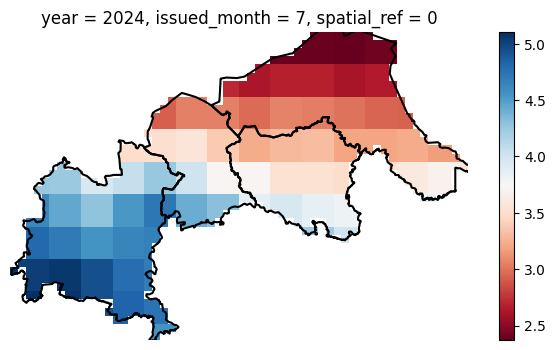

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
da_seas5_clip.isel(year=-1, issued_month=1).plot(ax=ax, cmap="RdBu")
adm1.boundary.plot(ax=ax, color="k")
ax.axis("off")

### Calculate mean

Computing and plotting things as I go just to ensure they look sensible.

In [11]:
da_seas5_mean = da_seas5_clip.mean(dim="year")

In [12]:
with ProgressBar():
    da_seas5_mean_computed = da_seas5_mean.compute()

[########################################] | 100% Completed | 91.45 s


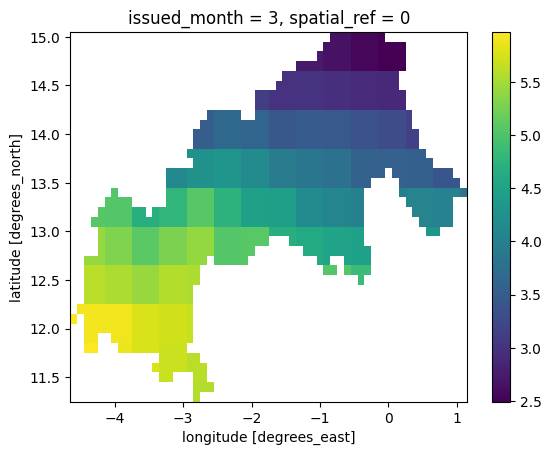

In [17]:
da_seas5_mean_computed.isel(issued_month=0).plot()

### Calculate std dev

In [12]:
da_seas5_std = da_seas5_clip.std(dim="year")

In [13]:
da_seas5_std

<xarray.DataArray (issued_month: 2, y: 38, x: 58)> Size: 18kB
dask.array<_sqrt, shape=(2, 38, 58), dtype=float32, chunksize=(1, 38, 58), chunktype=numpy.ndarray>
Coordinates:
  * issued_month  (issued_month) int64 16B 3 7
  * x             (x) float64 464B -4.6 -4.5 -4.4 -4.3 -4.2 ... 0.8 0.9 1.0 1.1
  * y             (y) float64 304B 11.3 11.4 11.5 11.6 ... 14.7 14.8 14.9 15.0
    spatial_ref   int64 8B 0

In [20]:
with ProgressBar():
    da_seas5_std_computed = da_seas5_std.compute()

[####################                    ] | 50% Completed | 49.25 ss

/Users/tdowning/.pyenv/versions/pa-aa-bfa-drought/lib/python3.11/site-packages/dask/array/numpy_compat.py:56: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


[########################################] | 100% Completed | 89.04 s


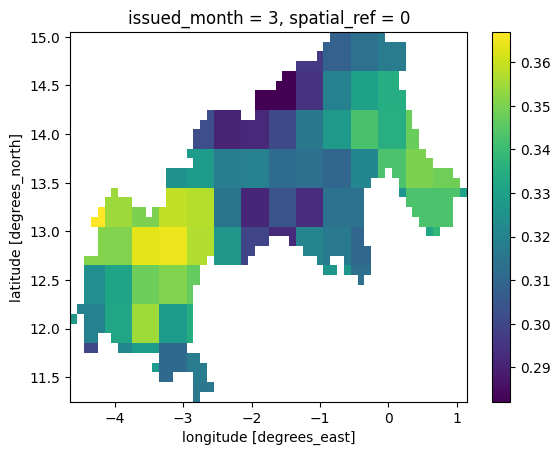

In [113]:
da_seas5_std_computed.isel(issued_month=0).plot()

In [14]:
da_seas5_variability = da_seas5_std / da_seas5_mean

In [17]:
with ProgressBar():
    da_seas5_variability_computed = da_seas5_variability.compute()

[####################                    ] | 50% Completed | 110.31 s

/Users/tdowning/.pyenv/versions/pa-aa-bfa-drought/lib/python3.11/site-packages/dask/array/numpy_compat.py:56: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


[########################################] | 100% Completed | 233.44 s


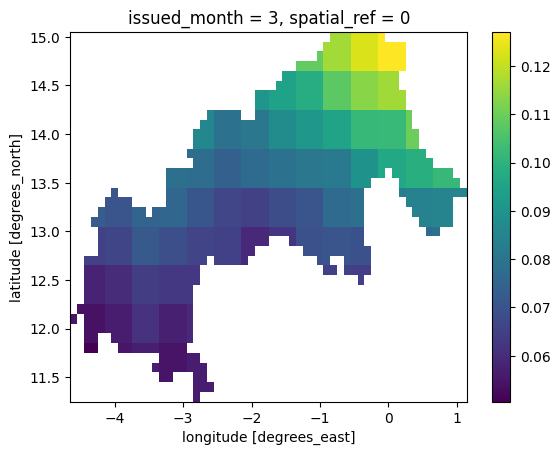

In [20]:
da_seas5_variability_computed.isel(issued_month=0).plot()

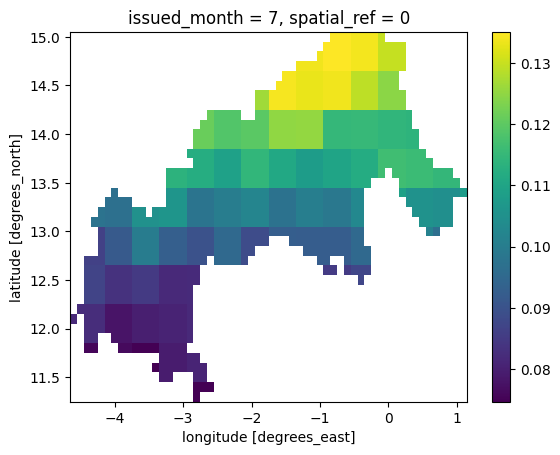

In [21]:
da_seas5_variability_computed.isel(issued_month=1).plot()

### Calculate Z-score

In [22]:
da_seas5_zscore = (da_seas5_clip - da_seas5_mean) / da_seas5_std

In [23]:
with ProgressBar():
    da_seas5_zscore_computed = da_seas5_zscore.compute()

[####################                    ] | 50% Completed | 141.49 s

/Users/tdowning/.pyenv/versions/pa-aa-bfa-drought/lib/python3.11/site-packages/dask/array/numpy_compat.py:56: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


[########################################] | 100% Completed | 279.42 s


(-4.6500000000099675,
 1.1499999999897028,
 11.249999999994245,
 15.049999999994029)

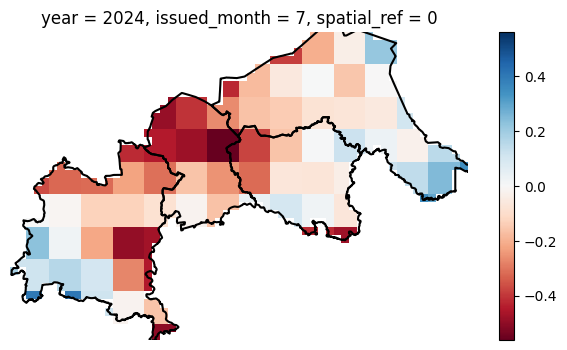

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
da_seas5_zscore_computed.isel(year=-1, issued_month=1).plot(ax=ax, cmap="RdBu")
adm1.boundary.plot(ax=ax, color="k")
ax.axis("off")

In [30]:
vmin = da_seas5_zscore_computed.sel(year=2019, issued_month=3).min()
vmax = -vmin

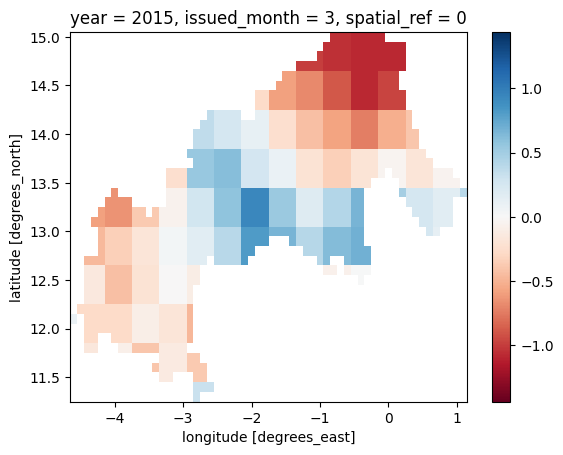

In [32]:
da_seas5_zscore_computed.sel(year=2015, issued_month=3).plot(
    vmin=vmin, vmax=vmax, cmap="RdBu"
)

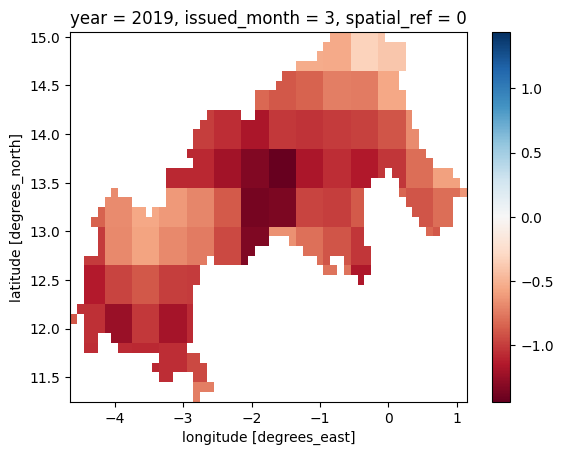

In [34]:
da_seas5_zscore_computed.sel(year=2019, issued_month=3).plot(
    vmin=vmin, vmax=vmax, cmap="RdBu"
)

In [26]:
da_seas5_zscore_q = da_seas5_zscore.quantile(q=ORIGINAL_Q, dim=["x", "y"])

In [32]:
with ProgressBar():
    da_seas5_zscore_q_computed = da_seas5_zscore_q.compute()

[####################                    ] | 50% Completed | 51.31 ss

/Users/tdowning/.pyenv/versions/pa-aa-bfa-drought/lib/python3.11/site-packages/dask/array/numpy_compat.py:56: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


[########################################] | 100% Completed | 90.40 s


In [24]:
da_seas5_zscore_q_computed.isel(issued_month=0).plot()

NameError: name 'da_seas5_zscore_q_computed' is not defined

### Write to `df` and save to blob

In [41]:
df_seas5_zscore_q = da_seas5_zscore_q_computed.to_dataframe("q")[
    "q"
].reset_index()

<Axes: >

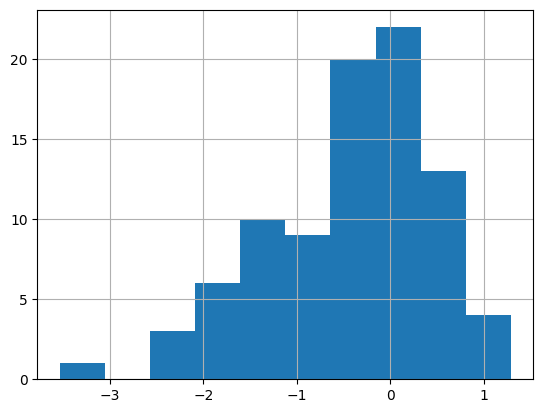

In [53]:
df_seas5_zscore_q["q"].hist()

In [50]:
df_seas5_zscore_q["q"].quantile(1 / 3)

-0.6227373480796816

In [54]:
df_seas5_zscore_q

,year,issued_month,q
0,1981,3,-0.320879
1,1981,7,-0.857055
2,1982,3,-0.188133
3,1982,7,-1.848775
4,1983,3,-2.532976
...,...,...,...
83,2022,7,0.714136
84,2023,3,-0.106452
85,2023,7,0.940906
86,2024,3,0.141914


<!-- markdownlint-disable MD013 -->

In [1]:
blob_name = f"{blob_utils.PROJECT_PREFIX}/processed/seas5/seas5_zscore_q10.parquet"  # noqa
blob_utils.upload_parquet_to_blob(df_seas5_zscore_q, blob_name)

NameError: name 'blob_utils' is not defined

In [58]:
df_seas5 = df_seas5_zscore_q.copy()

## SEAS5

### Loading and processing

In [47]:
# if needed, process SEAS5 rasters (takes a few minutes)
# seas5.process_seas5_rasters()

In [79]:
df_seas5 = seas5.load_seas5_stats(variable="zscore")

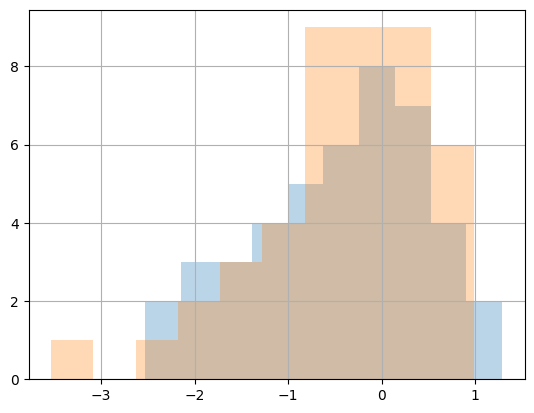

In [99]:
# just check the histogram to see that it's sensible
for issued_month, group in df_seas5.groupby("issued_month"):
    group["q"].hist(alpha=0.3)

In [81]:
df_seas5 = calculate_groups_rp(df_seas5, ["issued_month"])

In [82]:
df_seas5

,issued_month,year,q,q_rank,q_rp
0,3,1981,-0.320879,20.0,2.250000
1,3,1982,-0.188133,25.0,1.800000
2,3,1983,-2.532976,1.0,45.000000
3,3,1984,-2.072984,3.0,15.000000
4,3,1985,-0.123063,28.0,1.607143
...,...,...,...,...,...
83,7,2020,-0.768429,12.0,3.750000
84,7,2021,0.112688,30.0,1.500000
85,7,2022,0.714136,42.0,1.071429
86,7,2023,0.940906,43.0,1.046512


### Checking combined RP

In [63]:
df_pivot_rps = df_seas5.pivot(
    index="year", columns="issued_month", values="q_rp"
).reset_index()
df_pivot_rps = df_pivot_rps.rename(columns={x: f"issued_{x}" for x in [3, 7]})

In [64]:
dicts = []
min_individual_rp = 2

rp_list = df_seas5["q_rp"].unique()
rp_list = rp_list[rp_list >= min_individual_rp]
for rp_3 in rp_list:
    for rp_7 in rp_list:
        dff = df_pivot_rps[
            (df_pivot_rps["issued_3"] >= rp_3)
            | (df_pivot_rps["issued_7"] >= rp_7)
        ]
        dicts.append(
            {
                "rp_3": rp_3,
                "rp_7": rp_7,
                "rp_overall": (df_seas5["year"].nunique() + 1)
                / dff["year"].nunique(),
            }
        )
df_rps = pd.DataFrame(dicts)

In [65]:
heatmap_data = df_rps.pivot(index="rp_7", columns="rp_3", values="rp_overall")

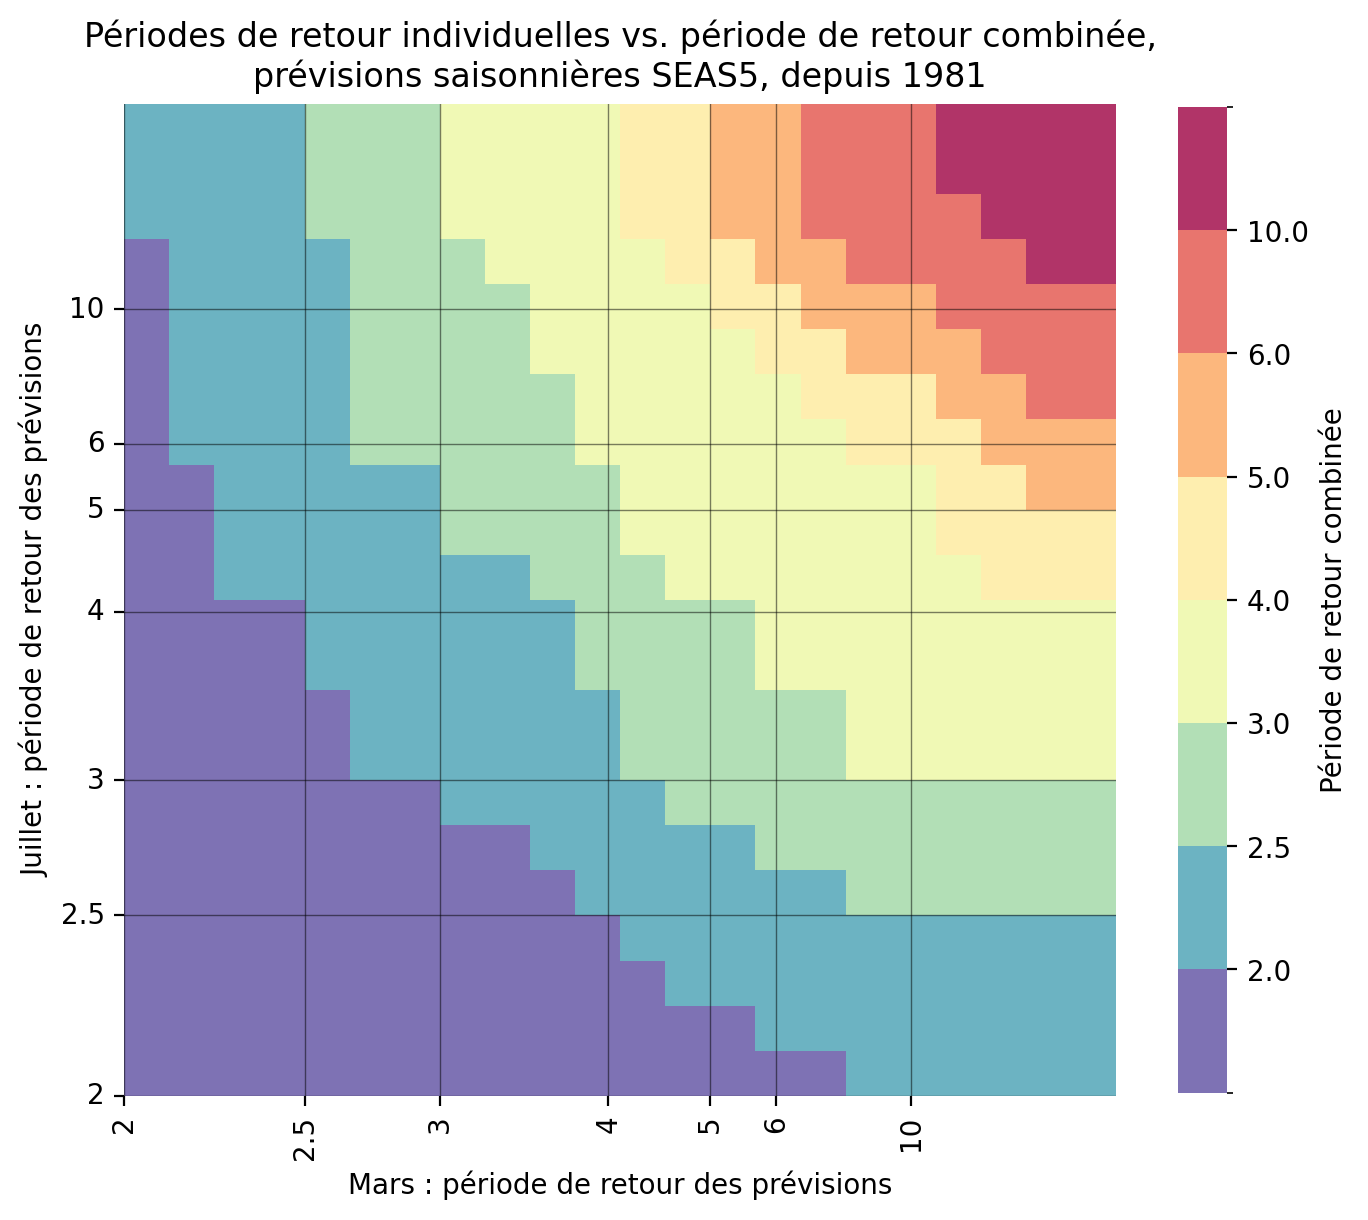

In [66]:
bounds = [1, 2, 2.5, 3, 4, 5, 6, 10, 1000]
tick_bounds = bounds[1:-1]
cmap = plt.cm.Spectral_r
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(dpi=200, figsize=(8, 8))

sns.heatmap(
    heatmap_data,
    annot=False,
    cmap=cmap,
    norm=norm,
    alpha=0.8,
    cbar_kws={
        "label": "Période de retour combinée",
        "ticks": tick_bounds,
        "shrink": 0.8,
    },
    ax=ax,
)
ax.invert_yaxis()
ax.set_aspect("equal", adjustable="box")
ax.set_title(
    "Périodes de retour individuelles vs. période de retour combinée,\n"
    f"prévisions saisonnières SEAS5, depuis {df_seas5['year'].min()}"
)
ax.set_xlabel("Mars : période de retour des prévisions")
ax.set_ylabel("Juillet : période de retour des prévisions")

tick_positions = np.interp(
    tick_bounds, heatmap_data.columns, range(len(heatmap_data.columns))
)
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_bounds, rotation=90)
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_bounds)

for x in tick_positions:
    ax.axvline(x, color="k", alpha=0.5, linewidth=0.5)
    ax.axhline(x, color="k", alpha=0.5, linewidth=0.5)

plt.show()

### Check trend

In [67]:
df_pivot = df_seas5.pivot(
    index="year", columns="issued_month", values="q"
).reset_index()
df_pivot = df_pivot.rename(columns={x: f"issued_{x}" for x in [3, 7]})

<Axes: xlabel='year'>

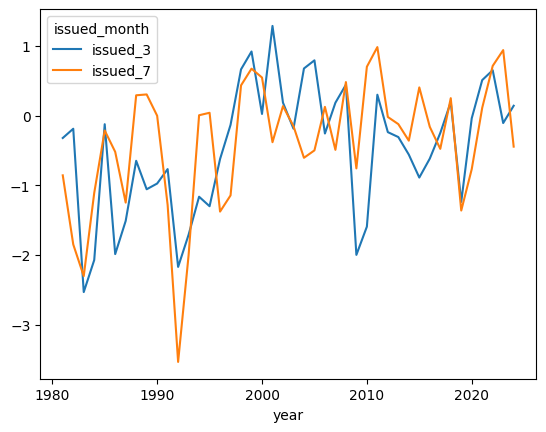

In [68]:
df_pivot.plot(x="year", y=["issued_3", "issued_7"])

In [69]:
for issued_month in [3, 7]:
    X = sm.add_constant(df_pivot.index)
    model = sm.OLS(df_pivot[f"issued_{issued_month}"], X).fit()
    print(f"issued month {issued_month}")
    print(model.summary())

issued month 3
                            OLS Regression Results                            
Dep. Variable:               issued_3   R-squared:                       0.169
Model:                            OLS   Adj. R-squared:                  0.149
Method:                 Least Squares   F-statistic:                     8.534
Date:                Mon, 17 Feb 2025   Prob (F-statistic):            0.00559
Time:                        20:24:56   Log-Likelihood:                -54.347
No. Observations:                  44   AIC:                             112.7
Df Residuals:                      42   BIC:                             116.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1028      0.252     

Same as for absolute values -
as a crude check, we see that the confidence intervals for the slope are
positive. So we can try to filter to more recent years to hopefully
make it trendless.

In [70]:
min_year = 2000
df_pivot_recent = df_pivot[df_pivot["year"] >= min_year]

<Axes: xlabel='year'>

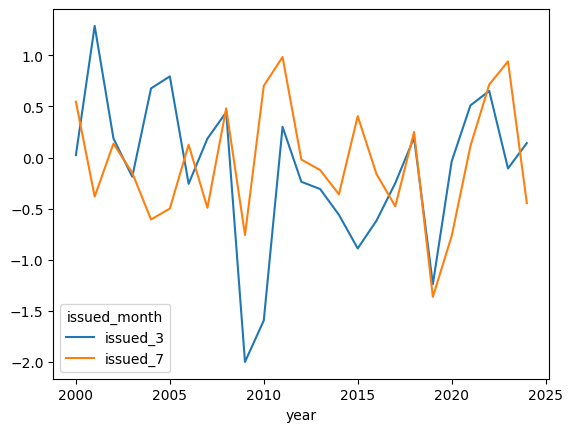

In [71]:
df_pivot_recent.plot(x="year", y=["issued_3", "issued_7"])

In [72]:
for issued_month in [3, 7]:
    X = sm.add_constant(df_pivot_recent.index)
    model = sm.OLS(df_pivot_recent[f"issued_{issued_month}"], X).fit()
    print(f"issued month {issued_month}")
    print(model.summary())

issued month 3
                            OLS Regression Results                            
Dep. Variable:               issued_3   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                 -0.015
Method:                 Least Squares   F-statistic:                    0.6488
Date:                Mon, 17 Feb 2025   Prob (F-statistic):              0.429
Time:                        20:25:08   Log-Likelihood:                -27.326
No. Observations:                  25   AIC:                             58.65
Df Residuals:                      23   BIC:                             61.09
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4060      0.664     

Confidence intervals of slope span 0 now, so we're good.

In [73]:
df_pivot_recent

issued_month,year,issued_3,issued_7
19,2000,0.024261,0.546936
20,2001,1.287865,-0.381315
21,2002,0.186523,0.136433
22,2003,-0.187278,-0.149781
23,2004,0.676953,-0.605415
24,2005,0.793959,-0.498821
25,2006,-0.256666,0.126075
26,2007,0.185495,-0.491156
27,2008,0.443560,0.481608
28,2009,-1.998934,-0.757412


### Plot historical activations

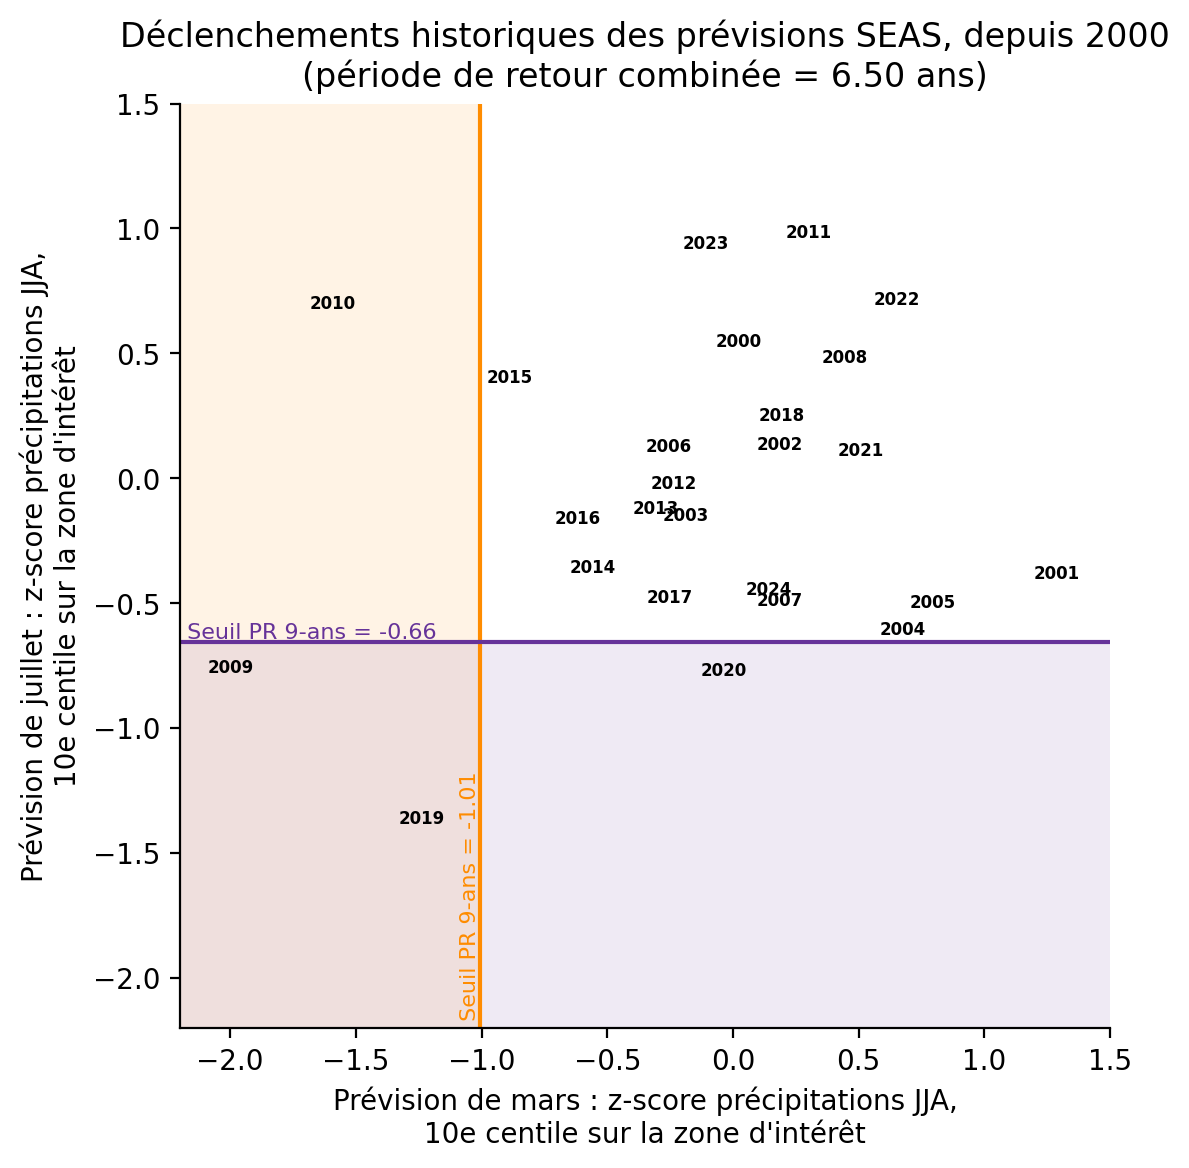

In [111]:
rp_individual_seas5 = 9

thresh_3 = df_pivot_recent["issued_3"].quantile(1 / rp_individual_seas5)
thresh_7 = df_pivot_recent["issued_7"].quantile(1 / rp_individual_seas5)

rp_overall = (len(df_pivot_recent) + 1) / df_pivot_recent[
    (df_pivot_recent["issued_3"] <= thresh_3)
    | (df_pivot_recent["issued_7"] <= thresh_7)
]["year"].nunique()

fig, ax = plt.subplots(dpi=200, figsize=(6, 6))

min_val = -2.2
max_val = 1.5
xmin = min_val
xmax = max_val
ymin = min_val
ymax = max_val

alpha = 0.1

color_3 = "darkorange"
ax.axvline(thresh_3, color=color_3)
ax.axvspan(xmin=xmin, xmax=thresh_3, facecolor=color_3, alpha=alpha)
ax.annotate(
    f" Seuil PR {rp_individual_seas5}-ans = {thresh_3:.2f}",
    (thresh_3, ymin),
    rotation=90,
    ha="right",
    va="bottom",
    fontsize=8,
    color=color_3,
)

color_7 = "rebeccapurple"
ax.axhline(thresh_7, color=color_7)
ax.axhspan(ymin=ymin, ymax=thresh_7, facecolor=color_7, alpha=alpha)
ax.annotate(
    f" Seuil PR {rp_individual_seas5}-ans = {thresh_7:.2f}",
    (xmin, thresh_7),
    ha="left",
    va="bottom",
    fontsize=8,
    color=color_7,
)

for year, row in df_pivot_recent.set_index("year").iterrows():
    ax.annotate(
        year,
        (row["issued_3"], row["issued_7"]),
        va="center",
        ha="center",
        fontsize=6,
        fontweight="bold",
    )

ax.set_xlim((xmin, xmax))
ax.set_ylim((ymin, ymax))

ax.set_xlabel(
    "Prévision de mars : z-score précipitations JJA,\n"
    "10e centile sur la zone d'intérêt"
)
ax.set_ylabel(
    "Prévision de juillet : z-score précipitations JJA,\n"
    "10e centile sur la zone d'intérêt"
)
ax.set_title(
    f"Déclenchements historiques des prévisions SEAS, depuis {min_year}\n"
    f"(période de retour combinée = {rp_overall:.2f} ans)"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

Fixing thresholds based on modeled RP (values calculated a few cells down), 
which were then rounded for proposal to working group, 
hence being hard-coded here.

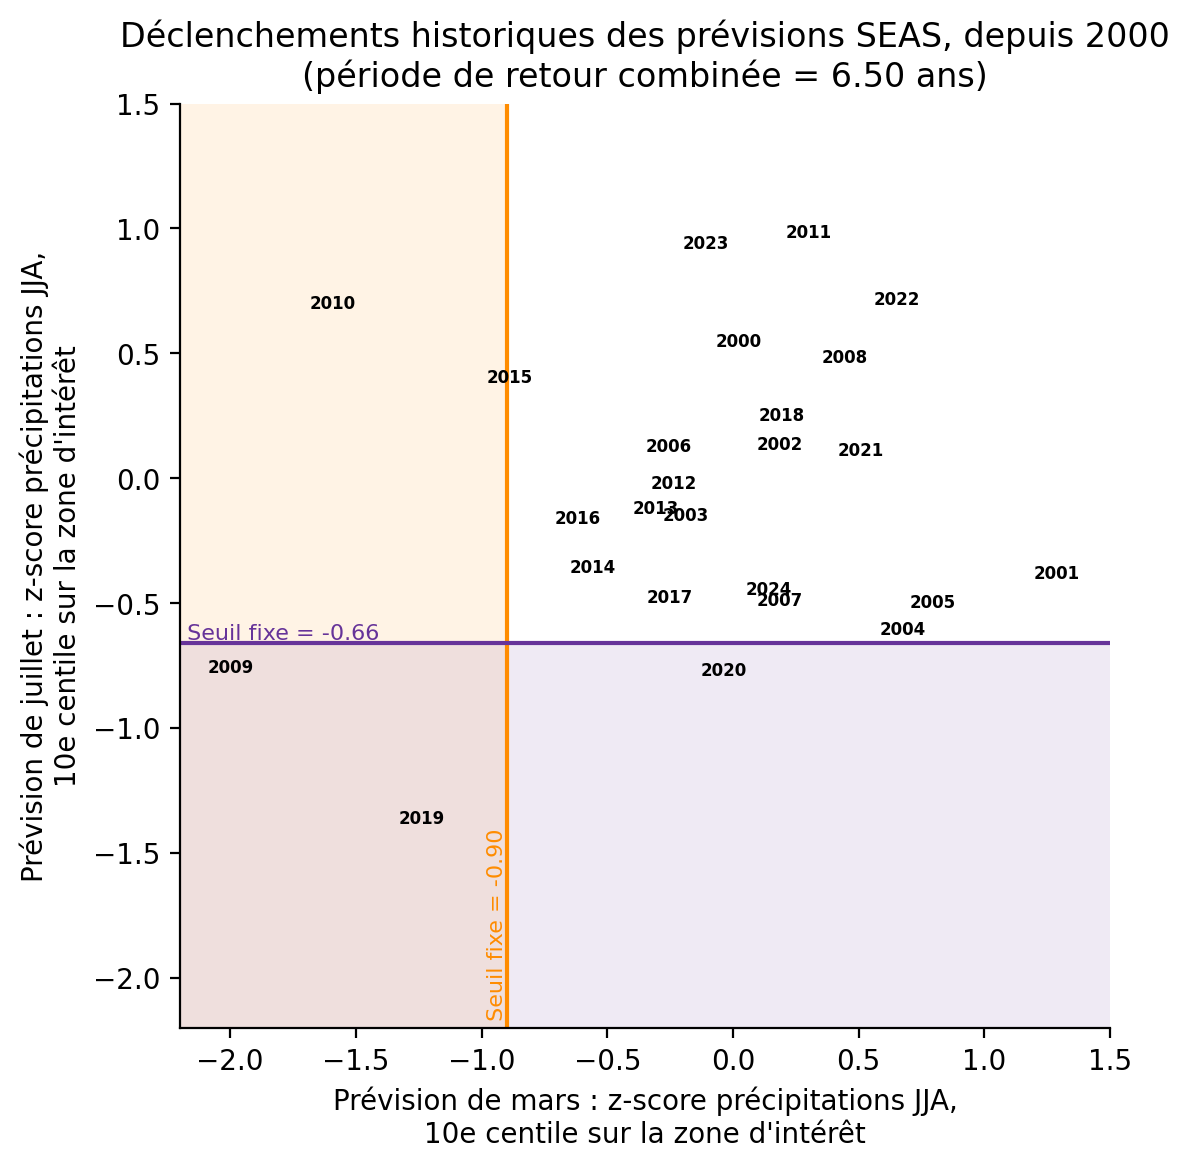

In [200]:
thresh_3 = -0.9
thresh_7 = -0.66

rp_overall = (len(df_pivot_recent) + 1) / df_pivot_recent[
    (df_pivot_recent["issued_3"] <= thresh_3)
    | (df_pivot_recent["issued_7"] <= thresh_7)
]["year"].nunique()

fig, ax = plt.subplots(dpi=200, figsize=(6, 6))

min_val = -2.2
max_val = 1.5
xmin = min_val
xmax = max_val
ymin = min_val
ymax = max_val

alpha = 0.1

color_3 = "darkorange"
ax.axvline(thresh_3, color=color_3)
ax.axvspan(xmin=xmin, xmax=thresh_3, facecolor=color_3, alpha=alpha)
ax.annotate(
    f" Seuil fixe = {thresh_3:.2f}",
    (thresh_3, ymin),
    rotation=90,
    ha="right",
    va="bottom",
    fontsize=8,
    color=color_3,
)

color_7 = "rebeccapurple"
ax.axhline(thresh_7, color=color_7)
ax.axhspan(ymin=ymin, ymax=thresh_7, facecolor=color_7, alpha=alpha)
ax.annotate(
    f" Seuil fixe = {thresh_7:.2f}",
    (xmin, thresh_7),
    ha="left",
    va="bottom",
    fontsize=8,
    color=color_7,
)

for year, row in df_pivot_recent.set_index("year").iterrows():
    ax.annotate(
        year,
        (row["issued_3"], row["issued_7"]),
        va="center",
        ha="center",
        fontsize=6,
        fontweight="bold",
    )

ax.set_xlim((xmin, xmax))
ax.set_ylim((ymin, ymax))

ax.set_xlabel(
    "Prévision de mars : z-score précipitations JJA,\n"
    "10e centile sur la zone d'intérêt"
)
ax.set_ylabel(
    "Prévision de juillet : z-score précipitations JJA,\n"
    "10e centile sur la zone d'intérêt"
)
ax.set_title(
    f"Déclenchements historiques des prévisions SEAS, depuis {min_year}\n"
    f"(période de retour combinée = {rp_overall:.2f} ans)"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

### Model RP

Modeling the RP using a skew normal distribution.
To me this seems reasonable, since the Z-scores are probably roughly normally distributed,
since we're not too close to zero.
But then, things get skewed because we're taking the 10th quantile.

Anyways, these are the values that are used in the framework.
I decided to use the modeled RP instead of the empirical because we can (hopefully)
better match the RPs across the issued months.
Either way, I still output the empirical RP just to check that we're still triggered for the
correct years (three per issue month, four overall).

In [180]:
def fit_skewnorm_rp(issued_month, rp_fit):
    # Fit the skewed normal distribution to the 'issued_3' column in df_pivot_recent
    params = skewnorm.fit(df_pivot_recent[f"issued_{issued_month}"])

    # Generate a range of values for plotting the PDF
    x = np.linspace(
        df_pivot_recent[f"issued_{issued_month}"].min() - 1,
        df_pivot_recent[f"issued_{issued_month}"].max() + 1,
        1000,
    )
    pdf_values = skewnorm.pdf(x, *params)

    # Create the histogram of the 'issued_3' column
    plt.figure(figsize=(8, 6))
    plt.hist(
        df_pivot_recent[f"issued_{issued_month}"],
        bins=30,
        density=True,
        alpha=0.6,
        color="g",
        label="Data Histogram",
    )

    # Plot the PDF of the fitted skewed normal distribution
    plt.plot(
        x, pdf_values, "r-", lw=2, label="Fitted Skewed Normal Distribution"
    )

    # Add labels and legend
    plt.title("Goodness of Fit: Skewed Normal Distribution")
    plt.xlabel(f"issued_{issued_month}")
    plt.ylabel("Density")
    plt.legend()

    # Show the plot
    plt.show()

    thresh = skewnorm.ppf(1 / rp_fit, *params)
    print(f"thresh for {rp_fit}-yr RP: {thresh}")
    n_trig_years = len(
        df_pivot_recent[df_pivot_recent[f"issued_{issued_month}"] <= thresh]
    )
    print(f"n years triggered with this thresh: {n_trig_years}")
    print(
        f"empirical RP with this thresh: {(len(df_pivot_recent)+1)/n_trig_years}"
    )

In [197]:
rp_fit = 7

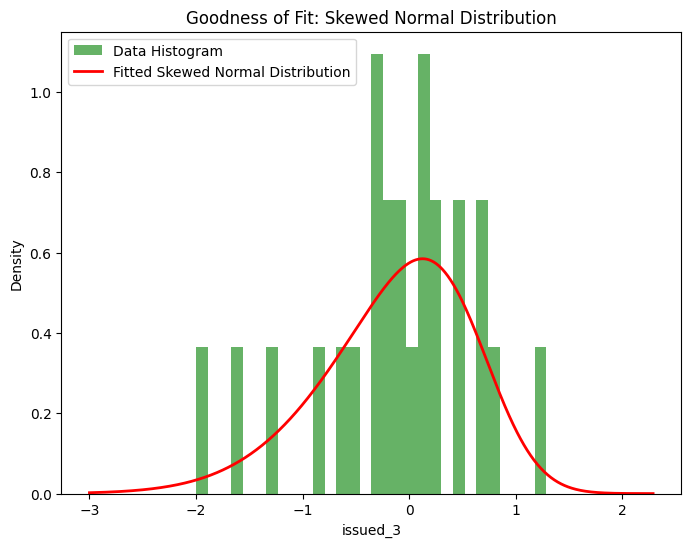

thresh for 7-yr RP: -0.902807192559968
n years triggered with this thresh: 3
empirical RP with this thresh: 8.666666666666666


In [198]:
fit_skewnorm_rp(3, rp_fit)

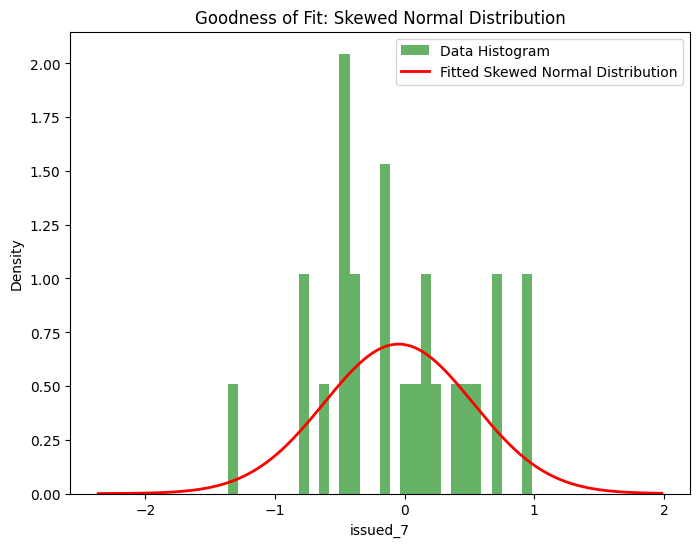

thresh for 7-yr RP: -0.6610107048200727
n years triggered with this thresh: 3
empirical RP with this thresh: 8.666666666666666


In [199]:
fit_skewnorm_rp(7, rp_fit)